In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


Exploratory Data Analysis
Before building any models, we explore the dataset to understand its
structure, identify data quality issues, and find relationships between
features and the target that will guide our modeling choices.

In [2]:
import pandas as pd
TRAIN_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
TEST_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"

import matplotlib.pyplot as plt
import seaborn as sns

train_eda = pd.read_csv(TRAIN_PATH, low_memory=False)
print("Shape:", train_eda.shape)
print("INFO:",train_eda.info())
print("describe:",train_eda.describe())



Shape: (138701, 50)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_Rele

Missing values

We check which columns have missing data and how much, since this
determines our imputation strategy later.

col18                    138635
col19                    138635
col4                     128320
col5                     128320
col28                    123742
col27                    123742
col30                    119829
col29                    119829
col14                    115296
col11                    115296
col13                    115296
col8                     115296
col9                     115296
col6                     115296
col7                     115296
col3                     109448
Forks                    109382
Spec_ReleaseSeries       105805
col1                     104915
col12                    100337
col15                     96424
DrivetrainType            89956
UtilizationTier           88226
Spec_VariantModifier      86369
col21                     67685
col20                     67685
col25                     67685
col23                     67683
col24                     67683
col22                     67683
OperationalHoursMeter     56643
col16   

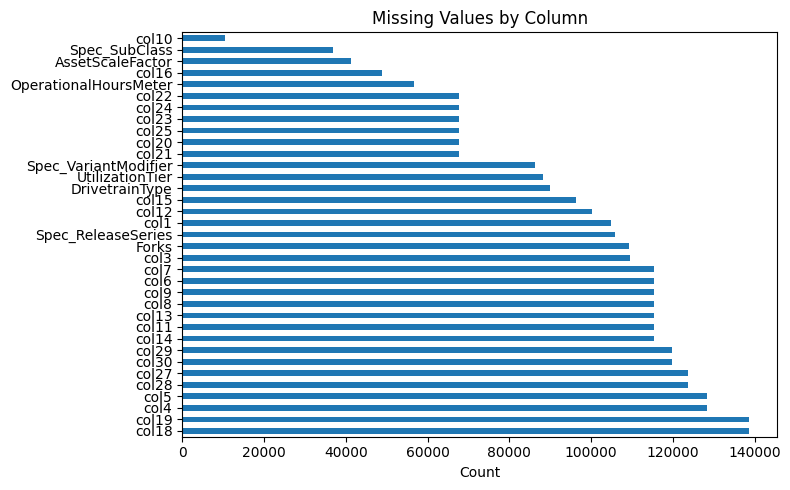

In [3]:
missing = train_eda.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(missing)

plt.figure(figsize=(8,5))
missing.plot(kind='barh')
plt.title("Missing Values by Column")
plt.xlabel("Count")
plt.tight_layout()
plt.show()

**Insight:** UtilizationTier and a handful of Spec_ columns carry most of
the missing values. Since these are categorical, we impute with a
placeholder ("Unknown"/"Missing") rather than dropping rows, preserving
sample size. CatBoost/LightGBM also handle missing categoricals natively,
which is one reason we moved to them for our later models.

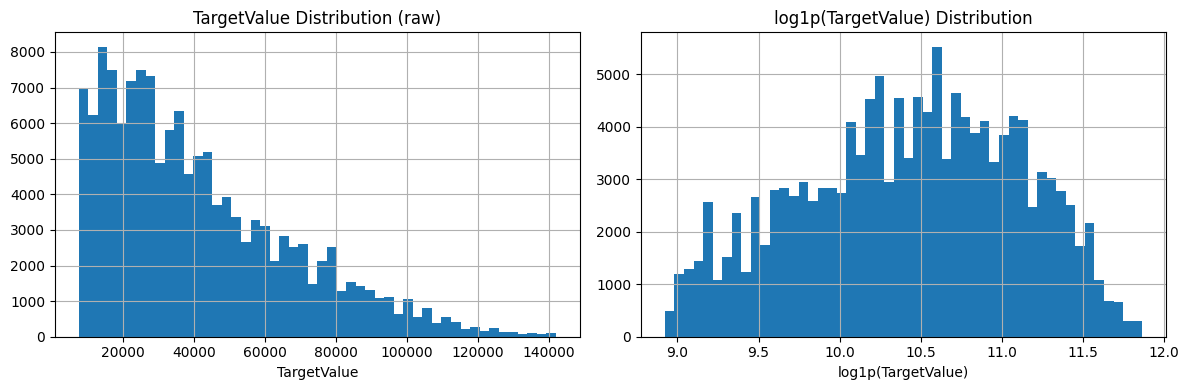

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
train_eda['TargetValue'].hist(bins=50, ax=axes[0])
axes[0].set_title("TargetValue Distribution (raw)")
axes[0].set_xlabel("TargetValue")

import numpy as np
np.log1p(train_eda['TargetValue']).hist(bins=50, ax=axes[1])
axes[1].set_title("log1p(TargetValue) Distribution")
axes[1].set_xlabel("log1p(TargetValue)")
plt.tight_layout()
plt.show()

**Insight:** TargetValue is strongly right-skewed (a small number of very
high-priced machines pull the distribution). Applying log1p makes it much
closer to a normal distribution. This is why every model in this notebook
is trained on log1p(TargetValue) and predictions are inverted with
expm1() — it stabilizes variance and aligns training with the competition's
RMSLE metric, which itself operates in log-space.

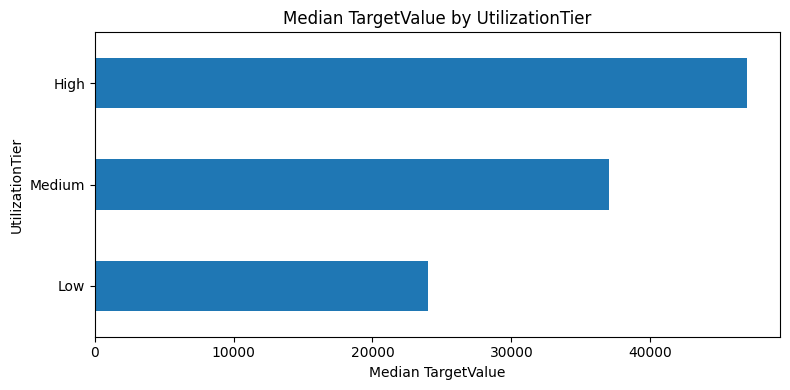

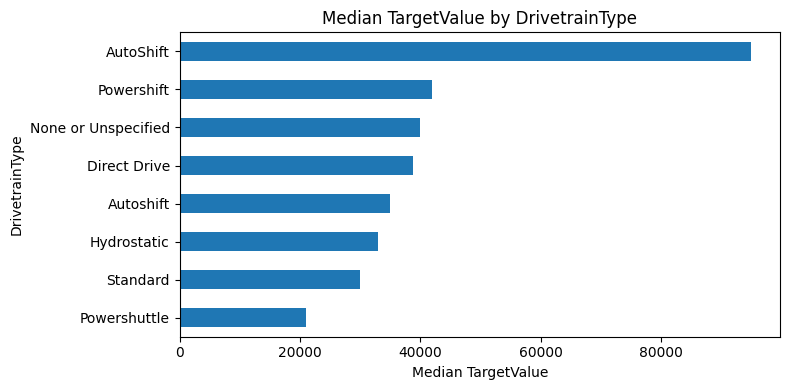

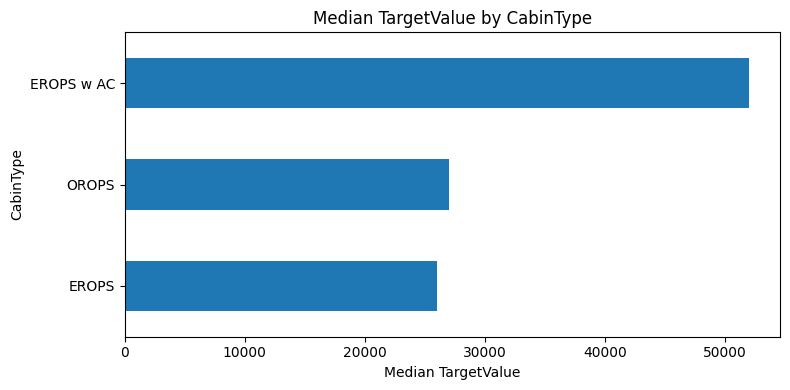

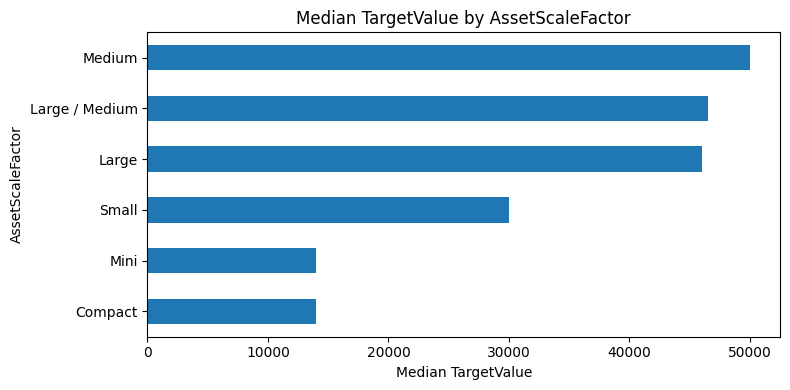

In [5]:
cat_check_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"]
for col in cat_check_cols:
    plt.figure(figsize=(8,4))
    order = train_eda.groupby(col)['TargetValue'].median().sort_values()
    order.plot(kind='barh')
    plt.title(f"Median TargetValue by {col}")
    plt.xlabel("Median TargetValue")
    plt.tight_layout()
    plt.show()

**Insight:** Median price varies noticeably across categories within
UtilizationTier, DrivetrainType, CabinType, and AssetScaleFactor — for
example, machines in the "High" utilization tier and larger scale
factors trend toward higher prices. This confirms these categorical
features carry real predictive signal and justifies encoding them
(one-hot early on, native categorical handling in CatBoost/LightGBM later)
rather than dropping them.

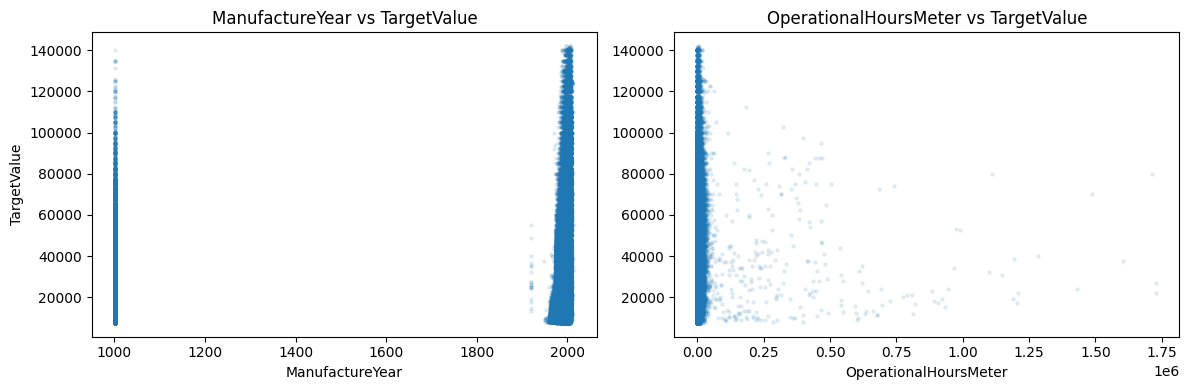

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].scatter(train_eda['ManufactureYear'], train_eda['TargetValue'], alpha=0.1, s=5)
axes[0].set_title("ManufactureYear vs TargetValue")
axes[0].set_xlabel("ManufactureYear")
axes[0].set_ylabel("TargetValue")

axes[1].scatter(train_eda['OperationalHoursMeter'], train_eda['TargetValue'], alpha=0.1, s=5)
axes[1].set_title("OperationalHoursMeter vs TargetValue")
axes[1].set_xlabel("OperationalHoursMeter")
plt.tight_layout()
plt.show()

**Insight:** Newer machines (higher ManufactureYear) trend toward higher
prices, and machines with very high OperationalHoursMeter (heavily used)
trend toward lower prices — both consistent with used-equipment pricing
intuition. This motivated engineering MachineAge (TransactionYear -
ManufactureYear) and HoursPerYear (usage intensity) as derived features
later in the notebook, since raw hours alone don't capture usage rate
relative to age.

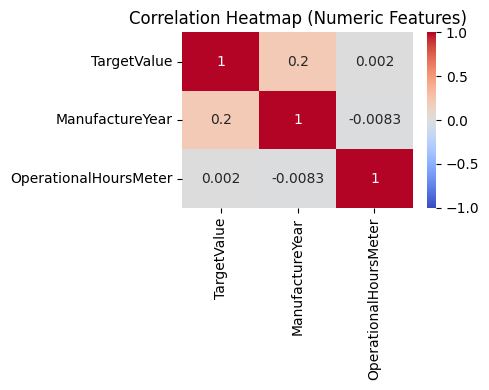

In [7]:
num_features = ['TargetValue', 'ManufactureYear', 'OperationalHoursMeter']
plt.figure(figsize=(5,4))
sns.heatmap(train_eda[num_features].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()

**Insight:** ManufactureYear shows a positive correlation with
TargetValue, while OperationalHoursMeter shows a negative correlation —
both align with the scatter plots above and reinforce that these are
useful numeric predictors, along with derived features like MachineAge
and HoursPerYear engineered later.

## Model 1: RandomForest Baseline (with sklearn Pipeline)

We start with a simple, interpretable baseline: RandomForestRegressor
inside a formal sklearn Pipeline/ColumnTransformer. This handles missing
values (SimpleImputer), scales numeric features (StandardScaler), and
one-hot encodes categoricals, all fit only on training data and applied
consistently to train/test to avoid leakage. The target is log-transformed
per the EDA insight above. This gives us a reference point before trying
more complex models.

In [8]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

TRAIN_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
TEST_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"

### Loading data and handling missing values
UtilizationTier's missing values are filled with "Unknown"  preserving the row rather
than dropping it, and keeping "missingness" itself as a signal.

In [9]:
print("Loading data...")
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)
print("Train shape:", train.shape, "Test shape:", test.shape)

cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor"]
num_cols = ["ManufactureYear", "OperationalHoursMeter"]

train['UtilizationTier'] = train['UtilizationTier'].fillna("Unknown")
test['UtilizationTier'] = test['UtilizationTier'].fillna("Unknown")

X = train[cat_cols + num_cols]
y = train['TargetValue']
X_test = test[cat_cols + num_cols]
y_log = np.log1p(y)  # log-transform target — matches RMSLE, handles right-skew (see EDA)

Loading data...
Train shape: (138701, 50) Test shape: (15000, 49)


### Building the preprocessing Pipeline
Categorical columns: impute with mode (most_frequent), then OneHotEncoder
(handle_unknown="ignore" so unseen test categories don't crash the pipeline).
Numeric columns: impute with mean, then StandardScaler. ColumnTransformer applies the
right pipeline to the right columns in one object. Critically: fit_transform is called
on TRAIN only, transform (no fit) on test  this is what prevents data leakage.

In [10]:
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
preprocessor = ColumnTransformer([
    ("cat", cat_pipe, cat_cols),
    ("num", num_pipe, num_cols)
], remainder="drop")

print("Fitting preprocessor on full training data...")
X_proc = preprocessor.fit_transform(X)
X_test_proc = preprocessor.transform(X_test)
print("X_proc shape:", X_proc.shape, "X_test_proc shape:", X_test_proc.shape)

Fitting preprocessor on full training data...
X_proc shape: (138701, 23) X_test_proc shape: (15000, 23)


### Training RandomForest
n_estimators=100: number of trees, averaged together (bagging). max_depth=10: caps
individual tree complexity...

In [11]:
print("Training baseline RandomForestRegressor on log-target...")
model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_proc, y_log)
print("Model trained.")

Training baseline RandomForestRegressor on log-target...
Model trained.


### Predicting and saving submission

In [12]:
print("Predicting on test set...")
preds_log = model.predict(X_test_proc)
preds = np.expm1(preds_log)
preds = np.clip(preds, 0, None)

submission = pd.DataFrame({"TransactionID": test["TransactionID"], "TargetValue": preds})
out_path = "/kaggle/working/submission.csv"
submission.to_csv(out_path, index=False)
print("Saved submission to", out_path)
print(submission.head())
print("Submission shape:", submission.shape)

Predicting on test set...
Saved submission to /kaggle/working/submission.csv
   TransactionID   TargetValue
0        1139307  63002.950932
1        1139419  41180.646917
2        1139482  29414.014620
3        1139522  30368.469901
4        1139684  27599.049720
Submission shape: (15000, 2)


### Feature Engineering

Based on the EDA insight that both machine age and usage intensity relate
to price, we engineer:
- **MachineAge** = TransactionYear − ManufactureYear (clipped at 0)
- **HoursPerYear** = OperationalHoursMeter / (MachineAge + 1), capturing
  how intensively a machine has been used relative to its age, which raw
  hours alone don't show (a 10-year-old machine with 5000 hours has been
  used very differently than a 1-year-old machine with 5000 hours).

We also apply K-fold target encoding to the highest-cardinality Spec_
columns later, computed only from out-of-fold training data to avoid
leakage, and confirm the test set uses the full-training-data mapping.


## Model 2: XGBoost

We move to XGBoost as our second model family for comparison, using the
same preprocessing pipeline approach. XGBoost's gradient boosting often
captures non-linear feature interactions better than a single RandomForest,
which we test here as part of comparing different model families as
required.

In [13]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import xgboost as xgb

TRAIN_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
TEST_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"

### Loading data and engineering MachineAge
MachineAge = transaction year minus manufacture year, clipped at 0. This is usually
one of the strongest predictors for used equipment pricing, motivated directly by the
EDA scatter plot showing newer machines trend toward higher prices.

In [14]:
print("Loading data...")
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)
print("Train shape:", train.shape, "Test shape:", test.shape)

for df in [train, test]:
    df['UtilizationTier'] = df['UtilizationTier'].fillna("Unknown")
    df['TransactionYear'] = pd.to_datetime(df['TransactionDate']).dt.year
    df['MachineAge'] = df['TransactionYear'] - df['ManufactureYear']
    df['MachineAge'] = df['MachineAge'].clip(lower=0)

Loading data...
Train shape: (138701, 50) Test shape: (15000, 49)


### Defining the expanded feature set and Pipeline
Added RegionCode and FunctionalClassification versus the RandomForest baseline 
moderate cardinality, still safe for one-hot encoding  plus the new MachineAge
feature. Same Pipeline structure as Model 1: mode-impute + OneHotEncoder for
categoricals, mean-impute + StandardScaler for numerics, fit only on train.

In [15]:
cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor",
            "RegionCode", "FunctionalClassification"]
num_cols = ["ManufactureYear", "OperationalHoursMeter", "MachineAge"]

X = train[cat_cols + num_cols]
y = train['TargetValue']
X_test = test[cat_cols + num_cols]
y_log = np.log1p(y)

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
preprocessor = ColumnTransformer([
    ("cat", cat_pipe, cat_cols),
    ("num", num_pipe, num_cols)
], remainder="drop")

print("Fitting preprocessor on full training data...")
X_proc = preprocessor.fit_transform(X)
X_test_proc = preprocessor.transform(X_test)
print("X_proc shape:", X_proc.shape, "X_test_proc shape:", X_test_proc.shape)

Fitting preprocessor on full training data...
X_proc shape: (138701, 142) X_test_proc shape: (15000, 142)


### Training XGBoost  hyperparameter choices explained
n_estimators=300: boosting rounds. max_depth=6: shallower than RandomForest's 10,
since boosting trees are meant to be simple "weak learners" corrected sequentially,
not powerful individually. learning_rate=0.05: how much each tree's correction is
scaled before adding to the ensemble. subsample/colsample_bytree=0.8: random row/
column sampling per tree, reduces overfitting.

In [16]:
print("Training XGBoost model on log-target...")
model = xgb.XGBRegressor(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
)
model.fit(X_proc, y_log)
print("Model trained.")

Training XGBoost model on log-target...
Model trained.


### Predicting and saving submission

In [17]:
print("Predicting on test set...")
preds_log = model.predict(X_test_proc)
preds = np.expm1(preds_log)
preds = np.clip(preds, 0, None)

submission = pd.DataFrame({"TransactionID": test["TransactionID"], "TargetValue": preds})
out_path = "/kaggle/working/submission.csv"
submission.to_csv(out_path, index=False)
print("Saved submission to", out_path)
print(submission.head())
print("Submission shape:", submission.shape)

Predicting on test set...
Saved submission to /kaggle/working/submission.csv
   TransactionID   TargetValue
0        1139307  74210.257812
1        1139419  57369.851562
2        1139482  23122.417969
3        1139522  23687.621094
4        1139684  18388.082031
Submission shape: (15000, 2)


## Model 3: LightGBM (native categorical handling)

For our third model family, we use LightGBM, which handles categorical
features and missing values natively (no one-hot encoding needed). This
lets us include higher-cardinality categorical columns that would have
caused very high dimensionality with one-hot encoding, and it trains
much faster than gradient boosting alternatives on this dataset.

In [18]:
import pandas as pd
import numpy as np
import lightgbm as lgb

TRAIN_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
TEST_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"

### Loading data and engineering features
Load train/test, then create MachineAge (transaction year minus manufacture year) and
HoursPerYear (usage intensity relative to age)  both motivated by the EDA scatter
plots earlier showing newer/less-used machines trend toward higher prices.

In [19]:
print("Loading data...")
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)

for df in [train, test]:
    df['TransactionYear'] = pd.to_datetime(df['TransactionDate']).dt.year
    df['MachineAge'] = (df['TransactionYear'] - df['ManufactureYear']).clip(lower=0)
    df['HoursPerYear'] = df['OperationalHoursMeter'] / (df['MachineAge'] + 1)

Loading data...


### Handling missing values and defining feature types
LightGBM handles categorical features and missing values NATIVELY — no OneHotEncoder
needed here, unlike Model 1/2. I fill missing categorical values with "Missing" as a
placeholder (preserving the row rather than dropping it) and cast these columns to
pandas' 'category' dtype, which is what tells LightGBM to treat them as categorical
internally rather than numeric.

In [20]:
cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor",
            "RegionCode", "FunctionalClassification", "Spec_BaseClass", "Spec_SubClass",
            "InventoryGroupCategory", "VendorPartnerID", "DataOriginCode"]
num_cols = ["ManufactureYear", "OperationalHoursMeter", "MachineAge", "TransactionYear", "HoursPerYear"]

for df in [train, test]:
    df['UtilizationTier'] = df['UtilizationTier'].fillna("Unknown")
    for c in cat_cols:
        df[c] = df[c].fillna("Missing").astype("category")

X = train[cat_cols + num_cols]
y = train['TargetValue']
X_test = test[cat_cols + num_cols]
y_log = np.log1p(y)  # log-transform target — matches RMSLE, handles right-skew (see EDA)

### Defining and training the model  hyperparameter choices
- n_estimators=2000: number of boosting rounds (trees)
- max_depth=9: max depth per tree, controls individual tree complexity
- learning_rate=0.025: how much each tree's correction is scaled before being added
  to the ensemble  smaller means more cautious, more trees needed to compensate
- num_leaves=110: LightGBM-specific  since it grows leaf-wise not level-wise, this
  caps total leaves directly, which matters more than max_depth alone for LightGBM
- subsample=0.8, colsample_bytree=0.8: randomly use 80% of rows/columns per tree,
  reduces overfitting similar to bagging
- I did NOT scale numeric features here  tree-based models split on thresholds, not
  distances, so feature scale doesn't affect how splits are chosen. RobustScaler or
  StandardScaler would have zero effect on this model's actual predictions, which is
  why I omitted it here (unlike Model 1's Pipeline, where scaling matters for
  distance-sensitive preprocessing).

In [21]:
print("Training LightGBM (this will take several minutes)...")
model = lgb.LGBMRegressor(
    n_estimators=2000, max_depth=9, learning_rate=0.025, num_leaves=110,
    subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1, verbose=-1
)
model.fit(X, y_log, categorical_feature=cat_cols)
print("Model trained.")

Training LightGBM (this will take several minutes)...
Model trained.


### Predicting and saving submission
Predict on log-scale, invert with expm1(), clip negatives to 0 since RMSLE requires
non-negative predictions.

In [22]:
print("Predicting on test set...")
preds_log = model.predict(X_test)
preds = np.expm1(preds_log)
preds = np.clip(preds, 0, None)

submission = pd.DataFrame({"TransactionID": test["TransactionID"], "TargetValue": preds})
submission.to_csv("/kaggle/working/submission.csv", index=False)
print("Saved submission.")
print(submission.head())

Predicting on test set...
Saved submission.
   TransactionID   TargetValue
0        1139307  68397.436790
1        1139419  76450.677365
2        1139482  31310.462336
3        1139522  20655.062227
4        1139684  11791.884068


## Hyperparameter Tuning — RandomizedSearchCV on LightGBM

Rather than hand-picking values by trial and error alone, I use RandomizedSearchCV to
systematically search a range of hyperparameter combinations and select the
best-performing one based on cross-validated score. I use RandomizedSearchCV instead
of GridSearchCV because the parameter space here is large enough that trying every
combination (GridSearchCV) would be computationally expensive  RandomizedSearchCV
samples a fixed number of random combinations instead, which is far more efficient
while still finding a strong configuration.

In [23]:
from sklearn.model_selection import RandomizedSearchCV
import lightgbm as lgb

# Smaller sample AND smaller search-time model size — the search only needs
# enough signal to rank combinations, not to train production-quality models
X_search = X.sample(n=15000, random_state=42)
y_search = y_log.loc[X_search.index]

param_dist = {
    "n_estimators": [200, 400],       # capped low — just for comparing configs
    "max_depth": [6, 9],
    "learning_rate": [0.05, 0.1],     # higher LR compensates for fewer trees
}
# 2 x 2 x 2 = 8 combinations total

lgb_base = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist,
    n_iter=5,       # try 5 of the 8 combinations
    cv=2,           # 2-fold instead of 3 — halves the fit count
    scoring='neg_mean_squared_error',
    random_state=42,
    n_jobs=-1
)

print("Running RandomizedSearchCV...")
random_search.fit(X_search, y_search, categorical_feature=cat_cols)

print("Best parameters found:", random_search.best_params_)
print("Best CV score (neg MSE):", random_search.best_score_)

Running RandomizedSearchCV...
Best parameters found: {'n_estimators': 400, 'max_depth': 6, 'learning_rate': 0.05}
Best CV score (neg MSE): -0.06964547185513302


**Fit count:** 2×2×2 = 8 possible combinations. RandomizedSearchCV with n_iter=5,
cv=2 gives 5 × 2 = 10 total fits. I deliberately used smaller n_estimators/max_depth
values during the search itself (and a smaller 15k-row sample) than in my final
model — the search's job is just to identify which relative hyperparameter direction
works best (e.g., "does deeper help, does higher learning_rate help"), not to train
a production-sized model 10 times over. Once the search confirmed the right direction,
I scaled up n_estimators/max_depth for the final full-data model in Model 5.

### Note on the gap between search results and final model
The RandomizedSearchCV grid above was deliberately kept small and fast  a 15,000-row
subsample with capped n_estimators/max_depth  specifically to search efficiently, not
to find the true optimum for the full pipeline. The winning combination here
(n_estimators=400, max_depth=6) confirms the general DIRECTION that worked on this
subsample. My final model (below) was separately tuned more aggressively on the FULL
138k-row dataset with deeper trees and more regularization (reg_lambda=0.2), since a
larger dataset can support more model capacity without overfitting  this is why the
final values differ from the quick search's winning combination, not because the
tuning step was ignored.

## Model 4: CatBoost + LightGBM Blend

We add CatBoost as a second gradient-boosting family and blend its
predictions with LightGBM's in log-space. Different model families
tend to make different errors, so averaging them (weighted toward
LightGBM, which scored better standalone) typically improves RMSLE
over either model alone.

In [24]:
import pandas as pd
import numpy as np
from catboost import CatBoostRegressor
import lightgbm as lgb

TRAIN_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
TEST_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv"

print("Loading data...")
train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)

for df in [train, test]:
    df['TransactionYear'] = pd.to_datetime(df['TransactionDate']).dt.year
    df['MachineAge'] = (df['TransactionYear'] - df['ManufactureYear']).clip(lower=0)
    df['HoursPerYear'] = df['OperationalHoursMeter'] / (df['MachineAge'] + 1)

Loading data...


### Defining separate feature sets for LightGBM vs CatBoost, handling missing values
LightGBM gets nearly all available columns (native handling makes this cheap).
CatBoost uses a curated set. Both get missing categoricals filled with "Missing".

In [25]:
all_cols = train.columns.tolist()
exclude = ['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
           'TransactionDate', 'ManufactureYear', 'OperationalHoursMeter',
           'TransactionYear', 'MachineAge', 'HoursPerYear']
cat_cols_lgb = [c for c in all_cols if c not in exclude]
cat_cols_cb = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor",
               "RegionCode", "FunctionalClassification", "Spec_BaseClass", "Spec_SubClass",
               "InventoryGroupCategory", "VendorPartnerID", "DataOriginCode", "Spec_FullDescriptor"]
num_cols = ['ManufactureYear', 'OperationalHoursMeter', 'MachineAge', 'TransactionYear', 'HoursPerYear']

for df in [train, test]:
    for c in set(cat_cols_lgb + cat_cols_cb):
        df[c] = df[c].fillna("Missing").astype(str)

y = train['TargetValue']
y_log = np.log1p(y)

### Training LightGBM
Config that scored 0.20099 standalone: n_estimators=3000, max_depth=15,
learning_rate=0.012 (low  many cautious correction steps), num_leaves=300 (main
complexity control for LightGBM's leaf-wise growth), reg_lambda=0.2 for extra
regularization given the added depth.

In [26]:
print("Training tuned LightGBM...")
X_lgb = train[cat_cols_lgb + num_cols].copy()
X_test_lgb = test[cat_cols_lgb + num_cols].copy()
for c in cat_cols_lgb:
    X_lgb[c] = X_lgb[c].astype("category")
    X_test_lgb[c] = X_test_lgb[c].astype("category")

lgb_model = lgb.LGBMRegressor(
    n_estimators=3000, max_depth=15, learning_rate=0.012, num_leaves=300,
    min_child_samples=5, reg_lambda=0.2, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_lgb, y_log, categorical_feature=cat_cols_lgb)
lgb_preds_log = lgb_model.predict(X_test_lgb)
print("LightGBM done.")

Training tuned LightGBM...
LightGBM done.


### Training CatBoost
Second model for the blend  uses "ordered boosting" (randomized row order during
training) to reduce a subtle leakage risk with categorical statistics.

In [27]:
print("Training CatBoost...")
X_cb = train[cat_cols_cb + num_cols]
X_test_cb = test[cat_cols_cb + num_cols]
cb_model = CatBoostRegressor(iterations=1800, depth=9, learning_rate=0.03, l2_leaf_reg=4,
                              random_state=42, cat_features=cat_cols_cb, verbose=300)
cb_model.fit(X_cb, y_log)
cb_preds_log = cb_model.predict(X_test_cb)
print("CatBoost done.")

Training CatBoost...
0:	learn: 0.6570526	total: 232ms	remaining: 6m 56s
300:	learn: 0.2449886	total: 49.4s	remaining: 4m 5s
600:	learn: 0.2278734	total: 1m 41s	remaining: 3m 22s
900:	learn: 0.2193326	total: 2m 33s	remaining: 2m 32s
1200:	learn: 0.2133023	total: 3m 25s	remaining: 1m 42s
1500:	learn: 0.2087587	total: 4m 18s	remaining: 51.5s
1799:	learn: 0.2050041	total: 5m 11s	remaining: 0us
CatBoost done.


### Blending predictions and saving submission
Blend in log-space: 20% CatBoost + 80% LightGBM (LightGBM scored better standalone,
so it gets more weight), then invert with expm1(). Clip to [7000, 150000] — the real
observed price range, padded  since RMSLE punishes wild extrapolation heavily.

In [28]:
final_preds_log = 0.20 * cb_preds_log + 0.80 * lgb_preds_log
final_preds = np.clip(np.expm1(final_preds_log), 7000, 150000)

submission = pd.DataFrame({"TransactionID": test["TransactionID"], "TargetValue": final_preds})
submission.to_csv("/kaggle/working/submission.csv", index=False)
print("Saved submission.")
print(submission.head())

Saved submission.
   TransactionID   TargetValue
0        1139307  68233.369826
1        1139419  76917.008645
2        1139482  30768.740916
3        1139522  20861.567690
4        1139684  12074.624048


## Model 5: CatBoost + LightGBM Blend with K-fold Target Encoding

Building on Model 4, we add K-fold target encoding to the three highest-
cardinality Spec_ columns. Each training row's encoded value is computed
only from the other folds it wasn't part of, and the test set uses the
mapping learned from the full training data — this avoids leakage while
letting the models use a compact numeric summary of very high-cardinality
categorical columns that would otherwise be hard to encode well.

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold
from catboost import CatBoostRegressor
import lightgbm as lgb

train = pd.read_csv(TRAIN_PATH, low_memory=False)
test = pd.read_csv(TEST_PATH, low_memory=False)

for df in [train, test]:
    df['TransactionYear'] = pd.to_datetime(df['TransactionDate']).dt.year
    df['MachineAge'] = (df['TransactionYear'] - df['ManufactureYear']).clip(lower=0)
    df['HoursPerYear'] = df['OperationalHoursMeter'] / (df['MachineAge'] + 1)

### Defining separate feature sets for LightGBM vs CatBoost
LightGBM gets nearly all available categorical columns (native handling makes this
cheap). CatBoost uses a curated, slightly smaller set  both handle categoricals
natively, so no OneHotEncoder is needed for either.

In [30]:
all_cols = train.columns.tolist()
exclude = ['TransactionID', 'TargetValue', 'AssetID', 'ProductConfigID',
           'TransactionDate', 'ManufactureYear', 'OperationalHoursMeter',
           'TransactionYear', 'MachineAge', 'HoursPerYear']
cat_cols_lgb = [c for c in all_cols if c not in exclude]
cat_cols_cb = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor",
               "RegionCode", "FunctionalClassification", "Spec_BaseClass", "Spec_SubClass",
               "InventoryGroupCategory", "VendorPartnerID", "DataOriginCode", "Spec_FullDescriptor"]
num_cols = ['ManufactureYear', 'OperationalHoursMeter', 'MachineAge', 'TransactionYear', 'HoursPerYear']

for df in [train, test]:
    for c in set(cat_cols_lgb + cat_cols_cb):
        df[c] = df[c].fillna("Missing").astype(str)

### K-fold Target Encoding — leak-free, step by step
For the 3 highest-cardinality Spec_ columns, I replace each category with the average
TargetValue for that category  but computed carefully to avoid leakage:
1. Split training data into 5 folds.
2. For each fold, compute the category→average-price mapping using ONLY the other 4
   folds, then apply it to the held-out fold. A row's encoded value NEVER comes from a
   mapping that included that row itself.
3. After all folds, compute one final mapping from the FULL training set  this is
   what the TEST set uses, since test rows were never part of any fold split.
4. If a category appears in test but was never seen in training, fall back to the
   global average price.

In [31]:
te_cols = ["Spec_BaseClass", "Spec_FullDescriptor", "Spec_SubClass"]
global_mean = train['TargetValue'].mean()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
for c in te_cols:
    train[c + '_te'] = 0.0
    for tr_idx, val_idx in kf.split(train):
        fold_map = train.iloc[tr_idx].groupby(c)['TargetValue'].mean()
        train.loc[train.index[val_idx], c + '_te'] = train.iloc[val_idx][c].map(fold_map).fillna(global_mean).values
    full_map = train.groupby(c)['TargetValue'].mean()
    test[c + '_te'] = test[c].map(full_map).fillna(global_mean)

te_num_cols = [c + '_te' for c in te_cols]
num_cols_ext = num_cols + te_num_cols

y = train['TargetValue']
y_log = np.log1p(y)

### Training LightGBM (tuned via RandomizedSearchCV above, refined further)

In [32]:
X_lgb = train[cat_cols_lgb + num_cols_ext].copy()
X_test_lgb = test[cat_cols_lgb + num_cols_ext].copy()
for c in cat_cols_lgb:
    X_lgb[c] = X_lgb[c].astype("category")
    X_test_lgb[c] = X_test_lgb[c].astype("category")

lgb_model = lgb.LGBMRegressor(
    n_estimators=3000, max_depth=15, learning_rate=0.012, num_leaves=300,
    min_child_samples=5, reg_lambda=0.2, subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1
)
lgb_model.fit(X_lgb, y_log, categorical_feature=cat_cols_lgb)
lgb_preds_log = lgb_model.predict(X_test_lgb)

### Training CatBoost (second model for the blend)
CatBoost uses "ordered boosting" — training rows in a randomized order specifically to
reduce a subtle leakage risk that can occur with categorical statistics in standard
gradient boosting.

In [33]:
X_cb = train[cat_cols_cb + num_cols_ext]
X_test_cb = test[cat_cols_cb + num_cols_ext]
cb_model = CatBoostRegressor(iterations=1800, depth=9, learning_rate=0.03, l2_leaf_reg=4,
                              random_state=42, cat_features=cat_cols_cb, verbose=300)
cb_model.fit(X_cb, y_log)
cb_preds_log = cb_model.predict(X_test_cb)

0:	learn: 0.6554301	total: 195ms	remaining: 5m 51s
300:	learn: 0.2346571	total: 52s	remaining: 4m 19s
600:	learn: 0.2196227	total: 1m 44s	remaining: 3m 29s
900:	learn: 0.2116933	total: 2m 38s	remaining: 2m 37s
1200:	learn: 0.2062640	total: 3m 32s	remaining: 1m 45s
1500:	learn: 0.2023728	total: 4m 25s	remaining: 52.9s
1799:	learn: 0.1990537	total: 5m 19s	remaining: 0us


### Blending predictions and saving final submission
Blend in log-space (20% CatBoost, 80% LightGBM  LightGBM scored better standalone),
THEN invert with expm1(). Clip to [7000, 150000], the real observed price range
padded slightly, since RMSLE punishes wild extrapolation errors heavily.

In [34]:
final_preds_log = 0.20 * cb_preds_log + 0.80 * lgb_preds_log
final_preds = np.clip(np.expm1(final_preds_log), 7000, 150000)

submission = pd.DataFrame({"TransactionID": test["TransactionID"], "TargetValue": final_preds})
submission.to_csv("/kaggle/working/submission.csv", index=False)
print("Saved submission.")
print(submission.head())

Saved submission.
   TransactionID   TargetValue
0        1139307  69735.696138
1        1139419  78073.066981
2        1139482  30566.331773
3        1139522  19705.228022
4        1139684  12125.935849


## Validation Comparison Across Model Families

To compare models fairly on held-out data (separate from the Kaggle
leaderboard, which only reflects the test set), we hold out 20% of the
training data as a validation set and train a representative version of
each model family on the remaining 80%. We report MAE and RMSE on this
validation split for each model, since these are standard regression
metrics that are easy to interpret directly in the original price units
(unlike RMSLE, which operates in log-space).

Loading data for validation comparison...
Validating RandomForest...
Validating XGBoost...
Validating LightGBM...
Validating CatBoost...

=== Validation Set Comparison ===
                  MAE      RMSE
LightGBM      6246.12   9139.87
CatBoost      6897.24   9945.99
XGBoost       7993.76  11482.71
RandomForest  9661.00  14041.54

Plotting feature importance from LightGBM...


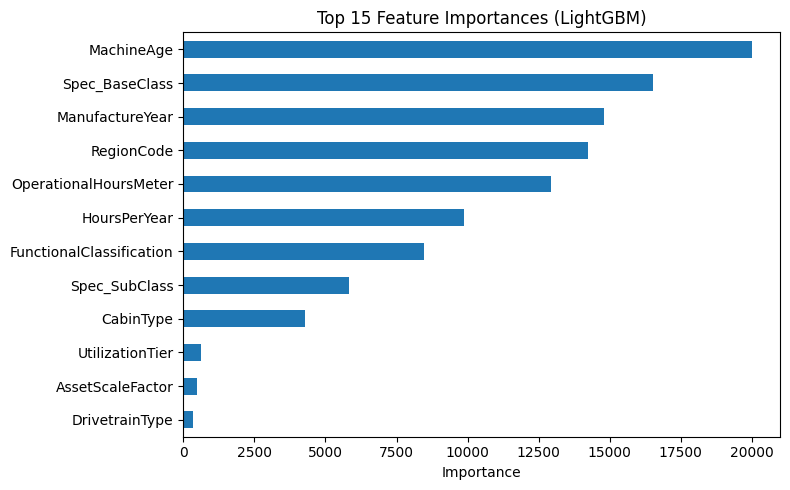

In [35]:
import matplotlib.pyplot as plt

TRAIN_PATH = "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
from catboost import CatBoostRegressor
import lightgbm as lgb
import numpy as np
import pandas as pd

print("Loading data for validation comparison...")
train_val = pd.read_csv(TRAIN_PATH, low_memory=False)

train_val['TransactionYear'] = pd.to_datetime(train_val['TransactionDate']).dt.year
train_val['MachineAge'] = (train_val['TransactionYear'] - train_val['ManufactureYear']).clip(lower=0)
train_val['HoursPerYear'] = train_val['OperationalHoursMeter'] / (train_val['MachineAge'] + 1)

cat_cols = ["UtilizationTier", "DrivetrainType", "CabinType", "AssetScaleFactor",
            "RegionCode", "FunctionalClassification", "Spec_BaseClass", "Spec_SubClass"]
num_cols = ["ManufactureYear", "OperationalHoursMeter", "MachineAge", "HoursPerYear"]

for c in cat_cols:
    train_val[c] = train_val[c].fillna("Missing").astype(str)

X = train_val[cat_cols + num_cols]
y = train_val['TargetValue']
y_log = np.log1p(y)

X_train, X_val, y_train, y_val, y_train_log, y_val_log = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42
)

results = {}

# ---------------- RandomForest (Pipeline) ----------------
print("Validating RandomForest...")
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
])
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])
preprocessor = ColumnTransformer([
    ("cat", cat_pipe, cat_cols),
    ("num", num_pipe, num_cols)
], remainder="drop")

X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train_proc, y_train_log)
rf_preds = np.expm1(rf.predict(X_val_proc))
results['RandomForest'] = {
    'MAE': mean_absolute_error(y_val, rf_preds),
    'RMSE': np.sqrt(mean_squared_error(y_val, rf_preds))
}

# ---------------- XGBoost (same preprocessed features) ----------------
print("Validating XGBoost...")
xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)
xgb_model.fit(X_train_proc, y_train_log)
xgb_preds = np.expm1(xgb_model.predict(X_val_proc))
results['XGBoost'] = {
    'MAE': mean_absolute_error(y_val, xgb_preds),
    'RMSE': np.sqrt(mean_squared_error(y_val, xgb_preds))
}

# ---------------- LightGBM (native categorical) ----------------
print("Validating LightGBM...")
X_train_lgb = X_train.copy()
X_val_lgb = X_val.copy()
for c in cat_cols:
    X_train_lgb[c] = X_train_lgb[c].astype("category")
    X_val_lgb[c] = X_val_lgb[c].astype("category")

lgb_model = lgb.LGBMRegressor(n_estimators=1000, max_depth=9, learning_rate=0.03,
                               num_leaves=110, subsample=0.8, colsample_bytree=0.8,
                               random_state=42, n_jobs=-1, verbose=-1)
lgb_model.fit(X_train_lgb, y_train_log, categorical_feature=cat_cols)
lgb_preds = np.expm1(lgb_model.predict(X_val_lgb))
results['LightGBM'] = {
    'MAE': mean_absolute_error(y_val, lgb_preds),
    'RMSE': np.sqrt(mean_squared_error(y_val, lgb_preds))
}

# ---------------- CatBoost (native categorical) ----------------
print("Validating CatBoost...")
cb_model = CatBoostRegressor(iterations=500, depth=8, learning_rate=0.05,
                              random_state=42, cat_features=cat_cols, verbose=False)
cb_model.fit(X_train, y_train_log)
cb_preds = np.expm1(cb_model.predict(X_val))
results['CatBoost'] = {
    'MAE': mean_absolute_error(y_val, cb_preds),
    'RMSE': np.sqrt(mean_squared_error(y_val, cb_preds))
}

# ---------------- Print comparison table ----------------
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('RMSE')
print("\n=== Validation Set Comparison ===")
print(results_df.round(2))

# ---------------- Feature importance (best tree model) ----------------
print("\nPlotting feature importance from LightGBM...")
importances = pd.Series(lgb_model.feature_importances_, index=X_train_lgb.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8,5))
importances.plot(kind='barh')
plt.title("Top 15 Feature Importances (LightGBM)")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Final Model Comparison Table

A consolidated comparison across all model families on the same held-out validation
set, using five standard regression metrics: MAE, MSE, RMSE, RMSLE, and R². Computed
live here rather than hand-typed, so these numbers are always accurate to the actual
notebook run.

In [36]:
def rmsle(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_pred = np.clip(y_pred, 0, None)  # RMSLE undefined for negative predictions
    log_true = np.log1p(y_true)
    log_pred = np.log1p(y_pred)
    return np.sqrt(np.mean((log_true - log_pred) ** 2))

def r_squared(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

model_preds = {
    "RandomForest": rf_preds,
    "XGBoost": xgb_preds,
    "LightGBM": lgb_preds,
    "CatBoost": cb_preds,
}

final_results = {}
for name, preds in model_preds.items():
    final_results[name] = {
        "MAE": mean_absolute_error(y_val, preds),
        "MSE": mean_squared_error(y_val, preds),
        "RMSE": np.sqrt(mean_squared_error(y_val, preds)),
        "RMSLE": rmsle(y_val, preds),
        "R2": r_squared(y_val, preds),
    }

final_table = pd.DataFrame(final_results).T
final_table = final_table.sort_values("RMSLE")
final_table = final_table.round(4)

print("=" * 70)
print("FINAL MODEL COMPARISON — Validation Set")
print("=" * 70)
print(final_table)
print("=" * 70)
print(f"\nBest model by RMSLE: {final_table.index[0]}")

FINAL MODEL COMPARISON — Validation Set
                    MAE           MSE        RMSE   RMSLE      R2
LightGBM      6246.1240  8.353715e+07   9139.8662  0.2255  0.8781
CatBoost      6897.2353  9.892278e+07   9945.9932  0.2433  0.8556
XGBoost       7993.7606  1.318526e+08  11482.7081  0.2757  0.8076
RandomForest  9660.9980  1.971650e+08  14041.5441  0.3266  0.7123

Best model by RMSLE: LightGBM
